In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
words = open('names.txt', 'r').read().splitlines()
words[:8]
len(words)

32033

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [140]:
block_size = 3
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [287]:
block_size = 3 
def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [85]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [62]:
C = torch.randn((27, 2))

In [63]:
C[5]

tensor([-1.0472, -1.3377])

In [64]:
F.one_hot(torch.tensor(5), num_classes=27)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [65]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-1.0472, -1.3377])

In [66]:
C[[5, 6, 7]]

tensor([[-1.0472, -1.3377],
        [-0.1651,  0.0688],
        [ 1.4532, -0.0062]])

In [67]:
C

tensor([[-0.3634, -1.8143],
        [ 1.7235, -1.2474],
        [ 0.0641, -0.3823],
        [ 3.2732, -0.0100],
        [ 0.7420, -2.2392],
        [-1.0472, -1.3377],
        [-0.1651,  0.0688],
        [ 1.4532, -0.0062],
        [-0.1733, -0.6563],
        [ 1.1081,  0.9640],
        [-0.1236,  1.8221],
        [ 0.7254, -0.2917],
        [ 0.3902, -0.6341],
        [ 0.8050, -1.0729],
        [-0.4219,  0.6829],
        [ 0.4530, -1.3855],
        [ 0.7377,  1.7310],
        [-0.4274,  1.8649],
        [ 1.3673,  0.3223],
        [-0.2543, -1.5059],
        [-1.2265,  0.5578],
        [ 0.8800, -0.7049],
        [ 1.2282, -1.5744],
        [ 1.1819, -0.7217],
        [ 0.5399,  0.1532],
        [ 0.2418,  1.1667],
        [-2.3301, -0.4738]])

In [68]:
C[[1, 2, 3]]

tensor([[ 1.7235, -1.2474],
        [ 0.0641, -0.3823],
        [ 3.2732, -0.0100]])

In [69]:
C[X]

tensor([[[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [-0.3634, -1.8143]],

        [[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [-1.0472, -1.3377]],

        [[-0.3634, -1.8143],
         [-1.0472, -1.3377],
         [ 0.8050, -1.0729]],

        [[-1.0472, -1.3377],
         [ 0.8050, -1.0729],
         [ 0.8050, -1.0729]],

        [[ 0.8050, -1.0729],
         [ 0.8050, -1.0729],
         [ 1.7235, -1.2474]],

        [[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [-0.3634, -1.8143]],

        [[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [ 0.4530, -1.3855]],

        [[-0.3634, -1.8143],
         [ 0.4530, -1.3855],
         [ 0.3902, -0.6341]],

        [[ 0.4530, -1.3855],
         [ 0.3902, -0.6341],
         [ 1.1081,  0.9640]],

        [[ 0.3902, -0.6341],
         [ 1.1081,  0.9640],
         [ 1.2282, -1.5744]],

        [[ 1.1081,  0.9640],
         [ 1.2282, -1.5744],
         [ 1.1081,  0.9640]],

        [[ 1.2282, -1

In [70]:
X.shape

torch.Size([32, 3])

In [71]:
X[3, 2]

tensor(13)

In [72]:
C[X][3, 2]

tensor([ 0.8050, -1.0729])

In [73]:
emb = C[X]

In [74]:
emb.shape

torch.Size([32, 3, 2])

In [76]:
W1 = torch.randn(6, 100)
b1 = torch.randn(100)

In [79]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [80]:
emb

tensor([[[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [-0.3634, -1.8143]],

        [[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [-1.0472, -1.3377]],

        [[-0.3634, -1.8143],
         [-1.0472, -1.3377],
         [ 0.8050, -1.0729]],

        [[-1.0472, -1.3377],
         [ 0.8050, -1.0729],
         [ 0.8050, -1.0729]],

        [[ 0.8050, -1.0729],
         [ 0.8050, -1.0729],
         [ 1.7235, -1.2474]],

        [[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [-0.3634, -1.8143]],

        [[-0.3634, -1.8143],
         [-0.3634, -1.8143],
         [ 0.4530, -1.3855]],

        [[-0.3634, -1.8143],
         [ 0.4530, -1.3855],
         [ 0.3902, -0.6341]],

        [[ 0.4530, -1.3855],
         [ 0.3902, -0.6341],
         [ 1.1081,  0.9640]],

        [[ 0.3902, -0.6341],
         [ 1.1081,  0.9640],
         [ 1.2282, -1.5744]],

        [[ 1.1081,  0.9640],
         [ 1.2282, -1.5744],
         [ 1.1081,  0.9640]],

        [[ 1.2282, -1

In [81]:
torch.cat(emb[:, 0, :])

tensor([[-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [-1.0472, -1.3377],
        [ 0.8050, -1.0729],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [ 0.4530, -1.3855],
        [ 0.3902, -0.6341],
        [ 1.1081,  0.9640],
        [ 1.2282, -1.5744],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [ 1.7235, -1.2474],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [ 1.1081,  0.9640],
        [-0.2543, -1.5059],
        [ 1.7235, -1.2474],
        [ 0.0641, -0.3823],
        [-1.0472, -1.3377],
        [ 0.3902, -0.6341],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [-0.3634, -1.8143],
        [-0.2543, -1.5059],
        [ 0.4530, -1.3855],
        [ 0.7377,  1.7310],
        [-0.1733, -0.6563]])

In [102]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [87]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [88]:
logits = h @ W2 + b2

In [383]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [384]:
sum(p.nelement() for p in parameters)

17697

In [385]:
for p in parameters:
    p.requires_grad = True

In [386]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [394]:
lossi = []
stepi = []
lri = []

In [395]:
for i in range(50000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters:
        p.grad = None
    loss.backward()
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    lri.append(lr)
    stepi.append(i)
    lossi.append(loss.log10().item())
loss

tensor(2.1214, grad_fn=<NllLossBackward0>)

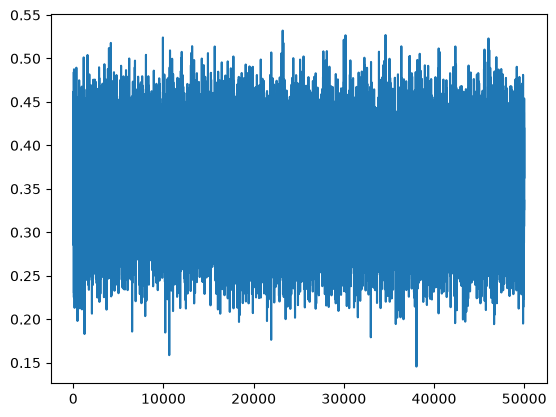

In [396]:
plt.plot(stepi, lossi)

In [295]:
# plt.plot(stepi, lossi)

In [296]:
#80% - training set - optimize the parameters
#10% - dev split - optimize hyperparameter - ex - size of emmbeding - 2, size of hidden layer - 100, etc..
#10% - test split - evaluate the model

In [399]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 +b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2671, grad_fn=<NllLossBackward0>)

In [397]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 +b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2868, grad_fn=<NllLossBackward0>)

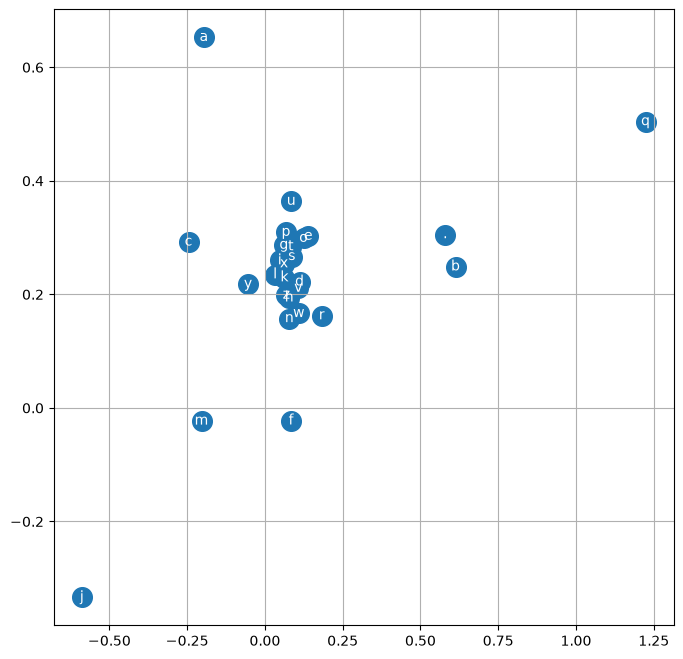

In [398]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')